(04-23-behavioral)=

# Behavioral finance en limits of arbitrage

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1979–2003, van prospect theory tot de survey van Barberis en Thaler.

**Wat we al weten.** Koersen bewegen meer dan dividendnieuws kan dragen
([](#03-15-shiller-excess-volatility)), en die surplusbeweglijkheid is hetzelfde feit als de
voorspelbaarheid van rendementen uit [](#04-20-voorspelbaarheid). In de cross-sectie zetten
winnaars een jaar door ([](#04-19-momentum)), en de verklaringen die daar werden genoemd
waren gedragsmodellen. [](#04-22-risk-management) liet zien hoe LTCM in 1998 ten onder
ging aan convergence trades die op termijn gelijk hadden: hefboom, mark-to-market en een
deadline zijn samen dodelijk.

**Welke vraag staat open.** Kunnen vergissingen van beleggers prijzen blijvend verschuiven
in een markt waar ook rationele arbitrageurs handelen, en zou dat er in de data anders
uitzien dan een beloning voor risico?
```

## Overzicht

De efficiënte-marktenhypothese rustte op een tweestappenargument. Beleggers zijn
rationeel; en voor zover ze dat niet zijn, heffen hun fouten elkaar op of worden ze door
arbitrageurs weggehandeld. Behavioral finance valt beide stappen aan. De eerste met
psychologie: Kahneman en Tversky lieten zien dat mensen keuzes onder risico systematisch
anders maken dan verwacht nut voorschrijft {cite}`KahnemanTversky1979,TverskyKahneman1992`.
De tweede met economie: arbitrage is zelf riskant en vraagt kapitaal, zodat
arbitrageurs een afwijking niet onbeperkt kunnen wegdrukken
{cite}`DeLongShleiferSummersWaldmann1990,ShleiferVishny1997`. Barberis en Thaler vatten het
veld in 2003 samen als precies die twee bouwstenen: *limits to arbitrage* en psychologie
{cite}`BarberisThaler2003`.

Het tijdvak definieert zich door een verschuiving in wat als bewijs telt. De Bondt en
Thaler vonden in 1985 dat de verliezers van de afgelopen drie tot vijf jaar de winnaars
daarna verslaan {cite}`DeBondtThaler1985`; Benartzi en Thaler dat een belegger die
verliezen zwaarder weegt dan winsten en zijn portefeuille elk jaar evalueert, precies de
equity premium eist die Mehra en Prescott niet konden verklaren {cite}`BenartziThaler1995`;
Odean en Barber dat particulieren winnaars te vroeg verkopen en te veel handelen
{cite}`Odean1998,BarberOdean2000,BarberOdean2001`. Epistemisch is dit motief 3: geen toets
verwerpt of bevestigt deze modellen; het zijn concurrerende verklaringen voor bekende feiten.

We leiden de premie van een myopisch loss-averse belegger af, bewijzen de prijsformule en
rendementsvoorwaarde van De Long, Shleifer, Summers en Waldmann, en werken het model van
Shleifer en Vishny uit. De simulatie vraagt of noise traders overleven en hoe gevoelig de
evaluatieperiode is voor een slecht gemeten premie. Aan het eind repliceren we de
lange-termijnomkering van De Bondt en Thaler, die het driefactormodel opslokt, en de
evaluatieperiode van Benartzi en Thaler.

In [1]:
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, special, stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Bied iemand een munt aan: kop wint hij 150 euro, munt verliest hij 100. De verwachte winst
is 25 euro, en toch weigeren de meeste mensen, terwijl verwacht nut bij zulke kleine bedragen
bijna risiconeutraliteit voorschrijft. Kahneman en Tversky verklaarden dat met drie
eigenschappen: mensen beoordelen winst en verlies ten opzichte van een referentiepunt, een
verlies doet ruwweg twee keer zoveel pijn als een even grote winst plezier doet (*loss
aversion*, verliesaversie), en binnen verliezen zoeken ze risico.

Dezelfde persoon neemt de gok vaak wel aan als hij hem vier keer mag spelen en alleen het
eindresultaat telt. Benartzi en Thaler zagen daarin de equity premium puzzle: aandelen zijn
over twintig jaar zelden een verlies, over één jaar vaak. Wie zijn portefeuille elk jaar
bekijkt en elk jaarverlies als verlies voelt (*myopic loss aversion*), eist een hoge premie.
Dezelfde neiging om rekeningen apart bij te houden, *mental accounting*
{cite}`Thaler1985,Thaler1999`, verklaart het *disposition effect* (winnaars te vroeg
verkopen, verliezers te lang vasthouden) {cite}`ShefrinStatman1985`.

Vergissingen verklaren nog geen prijzen: als een groep te optimistisch is, kopen rationele
beleggers minder. Tenzij tegenhandelen zelf riskant is. De Long, Shleifer, Summers en
Waldmann wezen erop dat het sentiment van morgen nog extremer kan zijn dan dat van vandaag.
Dat risico bestaat alleen door de noise traders, het is beprijsd, en daardoor kunnen noise
traders *meer* verdienen dan rationele beleggers: zij dragen meer van het risico dat ze zelf
veroorzaken. Santa-Clara haalt dit resultaat in zijn terugblik aan {cite}`SantaClara2026`.
Shleifer en Vishny voegden toe dat arbitrageurs andermans geld beleggen: hoe verder een prijs
wegdrijft, hoe meer geld inleggers terugtrekken, en hoe verder de prijs wegdrijft.

De markt levert zelf voorbeelden. Royal Dutch en Shell verdeelden sinds 1907 hun winst in een
verhouding van 60 tegen 40, maar hun koersen weken over 1980–1995 met 30% of meer van die
verhouding af {cite}`FrootDabora1999`. Op 2 maart 2000 bracht 3Com 5% van Palm naar de beurs
en beloofde de rest uit te delen, 1,525 Palm-aandeel per 3Com-aandeel. Palm sloot op 95,06
dollar, 3Com op 81,81: de waarde van 3Com zonder Palm was min 63 dollar per aandeel, min 22
miljard dollar {cite}`LamontThaler2003`. De arbitrage (koop 3Com, verkoop Palm short) was
moeilijk omdat Palm-aandelen schaars en duur te lenen waren.

## Toy-voorbeeld: een munt, twee keer gegooid, en een generatie noise traders

### (a) Prospect theory met de hand

Tversky en Kahneman schatten in 1992 de waardefunctie
$v(x) = x^{\alpha}$ voor $x \geq 0$ en $v(x) = -\lambda(-x)^{\alpha}$ voor $x < 0$, met
mediane waarden $\alpha = 0{,}88$ en $\lambda = 2{,}25$ {cite}`TverskyKahneman1992`. Neem
de gok $+150$ of $-100$ met kans $\tfrac12$. Zonder waarschijnlijkheidsweging is

$$
150^{0{,}88} = e^{0{,}88 \ln 150} = e^{4{,}4093} = 82{,}22,
\qquad
100^{0{,}88} = e^{0{,}88 \ln 100} = e^{4{,}0525} = 57{,}54,
$$

$$
V_1 = \tfrac12 (82{,}22) - \tfrac12 (2{,}25)(57{,}54) = 41{,}11 - 64{,}74 = -23{,}63 .
$$

De belegger weigert. Met de gewogen kansen van {cite:t}`TverskyKahneman1992`,
$w^{+}(\tfrac12) = 0{,}4206$ voor de winst en $w^{-}(\tfrac12) = 0{,}4540$ voor het verlies
(de formule volgt in de theorie), wordt de waarde $0{,}4206 \cdot 82{,}22 - 0{,}4540 \cdot
2{,}25 \cdot 57{,}54 = -24{,}20$.

Nu dezelfde gok twee keer, onafhankelijk, beoordeeld als één geheel. De uitkomsten zijn
$+300$ (kans $\tfrac14$), $+50$ (kans $\tfrac12$) en $-200$ (kans $\tfrac14$):

$$
V_2 = \tfrac14 \cdot 300^{0{,}88} + \tfrac12 \cdot 50^{0{,}88} - \tfrac14 \cdot 2{,}25 \cdot 200^{0{,}88}
= \tfrac14 (151{,}33) + \tfrac12 (31{,}25) - \tfrac14 (2{,}25)(105{,}90) = -6{,}11 .
$$

Wie de twee worpen elk apart beoordeelt, telt $2 \times -23{,}63 = -47{,}26$; wie ze samen
beoordeelt, $-6{,}11$. Hetzelfde risico, een andere boekhouding, en een acht keer kleiner
bezwaar. Zonder weging is de waarde bij vier worpen samen positief ($8{,}65$) en neemt de
belegger de gok aan; met de waarschijnlijkheidsweging, die het kleine kansje op het slechtste
verloop extra gewicht geeft, gebeurt dat pas bij vijf worpen ($0{,}11$).

In [2]:
ALPHA, LAMBDA, GAMMA_W, DELTA_W = 0.88, 2.25, 0.61, 0.69     # Tversky-Kahneman (1992)


def value(x, lam=LAMBDA):
    """Prospect theory value function v(x)."""
    x = np.asarray(x, dtype=float)
    return np.where(x >= 0, np.abs(x) ** ALPHA, -lam * np.abs(x) ** ALPHA)


def weight(p, c):
    """Tversky-Kahneman (1992) probability weighting function."""
    p = np.clip(p, 0.0, 1.0)
    return p**c / (p**c + (1 - p) ** c) ** (1 / c)


def cpt_equal(x, weighting=True, is_sorted=False, lam=LAMBDA):
    """CPT value of equally likely outcomes; each row of x is one prospect, returns one value per row."""
    x = np.atleast_2d(x)
    x = x if is_sorted else np.sort(x, axis=1)
    n = x.shape[1]
    k = np.arange(n)
    if weighting:
        w_loss = weight((k + 1) / n, DELTA_W) - weight(k / n, DELTA_W)            # rank from the bottom
        w_gain = weight((n - k) / n, GAMMA_W) - weight((n - k - 1) / n, GAMMA_W)  # rank from the top
    else:
        w_loss = w_gain = np.full(n, 1 / n)
    return (np.where(x < 0, w_loss, w_gain) * value(x, lam)).sum(axis=1)


def repeated_bet(n_plays, win=150.0, lose=-100.0):
    """All 2**n equally likely total outcomes of n independent plays."""
    return np.array([sum(s) for s in product([win, lose], repeat=n_plays)])


toy_pt = pd.DataFrame(
    {"waarde, zonder weging": [cpt_equal(repeated_bet(n), weighting=False).item() for n in range(1, 6)],
     "waarde, CPT met weging": [cpt_equal(repeated_bet(n)).item() for n in range(1, 6)]},
    index=pd.Index(range(1, 6), name="aantal worpen samen beoordeeld"),
)
print(f"w+(1/2) = {weight(0.5, GAMMA_W):.4f}, w-(1/2) = {weight(0.5, DELTA_W):.4f}")
print("code == handberekening:",
      np.allclose(toy_pt.iloc[:2, 0], [-23.63, -6.11], atol=0.005),
      np.isclose(toy_pt.iloc[0, 1], -24.20, atol=0.005))
toy_pt.round(2)

w+(1/2) = 0.4206, w-(1/2) = 0.4540
code == handberekening: True True


,"waarde, zonder weging","waarde, CPT met weging"
aantal worpen samen beoordeeld,,
1,-23.63,-24.20
2,-6.11,-17.27
3,-2.20,-17.00
4,8.65,-11.16
5,25.94,0.11


### (b) Een generatie noise traders

Een risicovol activum is er in vaste hoeveelheid 1 en keert in deze periode geen dividend
uit; een veilig activum heeft rendement nul. Een jonge belegger koopt vandaag tegen $p_t$
en verkoopt morgen aan de volgende generatie tegen $p_{t+1}$, die $1{,}2$ of $0{,}8$ is met
kans $\tfrac12$, afhankelijk van het sentiment van die generatie. Dus $\E_t[p_{t+1}] = 1$ en
$\Var_t(p_{t+1}) = 0{,}04$. Elke belegger maximaliseert $\E[w] - \gamma \Var(w)$ met
$2\gamma = 2{,}5$, zodat hij $\lambda = (\text{verwachte winst per stuk})/(2\gamma
\Var) = (\text{verwachte winst})/0{,}1$ stuks koopt. Een fractie $\mu = 0{,}25$ is noise
trader en denkt dat de prijs morgen gemiddeld $\rho_t = 0{,}2$ hoger is.

Marktevenwicht: $0{,}75 \cdot \frac{1 - p_t}{0{,}1} + 0{,}25 \cdot \frac{1{,}2 - p_t}{0{,}1}
= 1$, dus $1{,}05 - p_t = 0{,}1$ en $p_t = 0{,}95$. Zonder noise traders was de prijs
$0{,}90$ geweest. De sophisticated beleggers kopen $\lambda^{i} = 0{,}05/0{,}1 = 0{,}5$ stuks,
de noise traders $\lambda^{n} = 0{,}25/0{,}1 = 2{,}5$ (controle:
$0{,}75 \cdot 0{,}5 + 0{,}25 \cdot 2{,}5 = 1$). Stijgt de prijs naar $1{,}2$, dan verdient een
sophisticated belegger $0{,}5 \cdot 0{,}25 = 0{,}125$ en een noise trader $0{,}625$; daalt ze
naar $0{,}8$, dan is het $-0{,}075$ tegen $-0{,}375$. De verwachte winst is $0{,}025$ voor de
sophisticated belegger en $0{,}125$ voor de noise trader: vijf keer zoveel. Maar de
standaarddeviatie van de noise trader is $2{,}5 \cdot 0{,}2 = 0{,}5$, en zijn ware
doelfunctie is $0{,}125 - 1{,}25 \cdot 0{,}25 = -0{,}19$ tegen $0{,}025 - 1{,}25 \cdot 0{,}01
= 0{,}0125$. Hij verdient meer en is slechter af.

In [3]:
mu_n, rho_t, two_gamma = 0.25, 0.20, 2.5
p_next = np.array([1.2, 0.8])
e_next, var_next = p_next.mean(), p_next.var()


def excess_demand(p):
    """Aggregate demand for the risky asset minus supply 1."""
    lam_i = (e_next - p) / (two_gamma * var_next)
    lam_n = (e_next + rho_t - p) / (two_gamma * var_next)
    return (1 - mu_n) * lam_i + mu_n * lam_n - 1


p_t = optimize.brentq(excess_demand, 0.0, 2.0)
p_no_noise = e_next - two_gamma * var_next
lam = {"sophisticated": (e_next - p_t) / (two_gamma * var_next),
       "noise": (e_next + rho_t - p_t) / (two_gamma * var_next)}
toy_dssw = pd.DataFrame(
    {name: {"stuks": l, "winst als p=1.2": l * (1.2 - p_t), "winst als p=0.8": l * (0.8 - p_t),
            "verwachte winst": l * (e_next - p_t), "SD winst": l * np.sqrt(var_next),
            "E - gamma Var": l * (e_next - p_t) - two_gamma / 2 * l**2 * var_next}
     for name, l in lam.items()}
).T
print(f"p_t = {p_t:.4f}, zonder noise traders {p_no_noise:.4f}")
print("code == handberekening:", np.allclose([p_t, lam["sophisticated"], lam["noise"]], [0.95, 0.5, 2.5]))
toy_dssw.round(4)

p_t = 0.9500, zonder noise traders 0.9000
code == handberekening: True


,stuks,winst als p=1.2,winst als p=0.8,verwachte winst,SD winst,E - gamma Var
sophisticated,0.5,0.125,-0.075,0.025,0.1,0.0125
noise,2.5,0.625,-0.375,0.125,0.5,-0.1875


## Theorie

### Prospect theory

*Waarom zou dit waar zijn?* Een zintuig meet veranderingen, geen niveaus. Kahneman en
Tversky namen aan dat waardering net zo werkt: uitkomsten zijn winst of verlies ten opzichte
van een referentiepunt, de gevoeligheid neemt in beide richtingen af, en verlies weegt
zwaarder. Dat geeft een knik in het nulpunt, en een knik is genoeg om kleine gokken te
weigeren.

Een *prospect* is een loterij met uitkomsten $x_{-m} < \dots < x_{-1} < 0 \leq x_0 < \dots <
x_{k}$ en kansen $p_j$. Onder *cumulative prospect theory* (CPT) is de waarde

```{math}
:label: eq-behavioral-cpt
V = \sum_{j=-m}^{k} \pi_j\, v(x_j),
\qquad
v(x) = \begin{cases} x^{\alpha} & x \geq 0,\\ -\lambda(-x)^{\beta} & x < 0, \end{cases}
```

met beslisgewichten die niet de kansen zelf wegen maar de *cumulatieve* kansen,

```{math}
:label: eq-behavioral-weging
\pi_j = \begin{cases}
w^{+}\!\left(\textstyle\sum_{i \geq j} p_i\right) - w^{+}\!\left(\textstyle\sum_{i > j} p_i\right) & j \geq 0,\\[4pt]
w^{-}\!\left(\textstyle\sum_{i \leq j} p_i\right) - w^{-}\!\left(\textstyle\sum_{i < j} p_i\right) & j < 0,
\end{cases}
\qquad
w(p) = \frac{p^{c}}{\left(p^{c} + (1-p)^{c}\right)^{1/c}} .
```

De weegfunctie overschat kleine kansen; toegepast op cumulatieve kansen schendt ze geen
stochastische dominantie, het probleem van de versie uit 1979.
Tversky en Kahneman rapporteerden als medianen $\alpha = \beta = 0{,}88$, $\lambda = 2{,}25$,
$c = \gamma = 0{,}61$ voor winsten en $c = \delta = 0{,}69$ voor verliezen
{cite}`TverskyKahneman1992`. Wij noemen die weegparameters $\gamma_w$ en $\delta_w$, om ze
niet te verwarren met de risicoaversie $\gamma$ uit de notatietabel.

Twee eigenschappen doen het werk. Met $\alpha = \beta$ is $V(kX) = k^{\alpha}V(X)$ voor
$k > 0$, dus keuzes hangen niet af van de eenheid. En de risicoaversie bij de knik is van
*eerste orde*: een gok $\pm\varepsilon$ kost een verwachtnutbelegger orde $\varepsilon^{2}$,
een loss-averse belegger orde $\varepsilon$.

### Myopic loss aversion en de equity premium

*Waarom zou dit waar zijn?* Het verwachte rendement groeit lineair met de horizon, de
standaarddeviatie met de wortel. Over een korte horizon is de kans op verlies bijna een half,
over een lange klein. De premie die een belegger die verlies $\lambda$ keer zwaarder weegt
schadeloosstelt, daalt dus met de horizon, en omgekeerd verraadt de premie hoe vaak hij kijkt.

Neem de eenvoudigste versie: $\alpha = \beta = 1$, geen weging, een risicovrij alternatief met
rendement $r^{f}h$ over een horizon van $h$ jaar, en een aandelenrendement over die horizon
$X_h \sim \mathcal{N}\big((r^{f} + \mu^{e})h,\ \sigma^{2}h\big)$, met $\mu^{e}$ de equity premium
per jaar. De prospect-waarde is dan $V(X) = \E[X] - (\lambda - 1)\E[X^{-}]$, met
$X^{-} = \max(-X, 0)$.

:::{prf:proposition} De premie van een myopisch loss-averse belegger
:label: prop-behavioral-bt

De belegger is onverschillig tussen aandelen en de risicovrije belegging als

```{math}
:label: eq-behavioral-bt-exact
\mu^{e} h = (\lambda - 1)\left[\sigma\sqrt{h}\,\varphi(z) - (r^{f}+\mu^{e})h\,\Phi(-z)\right],
\qquad z = \frac{(r^{f}+\mu^{e})\sqrt{h}}{\sigma},
```

en voor kleine $z$ is de oplossing bij benadering

```{math}
:label: eq-behavioral-bt
\mu^{e}(h) \approx \frac{\lambda - 1}{\lambda + 1}\left(\sigma\sqrt{\frac{2}{\pi h}} - r^{f}\right),
\qquad
h^{*}(\mu^{e}) \approx \frac{2\sigma^{2}/\pi}{\left(r^{f} + \mu^{e}\,\frac{\lambda+1}{\lambda-1}\right)^{2}} .
```
:::

:::{prf:proof}
Omdat de risicovrije belegging geen verlies kent, is haar waarde $r^{f}h$. Voor
$X \sim \mathcal{N}(m, s^{2})$ is $\E[X^{-}] = \int_{-\infty}^{0}(-x)\,\frac1s\varphi\!\left(\frac{x-m}{s}\right)dx
= s\varphi(m/s) - m\Phi(-m/s)$, via de substitutie $u = (x - m)/s$ en
$\int_{-\infty}^{a} u\varphi(u)\,du = -\varphi(a)$. Gelijkstellen van
$(r^{f}+\mu^{e})h - (\lambda-1)\E[X_h^{-}]$ aan $r^{f}h$ geeft
[](#eq-behavioral-bt-exact). Voor kleine $z$ is $\varphi(z) \approx 1/\sqrt{2\pi}$ en
$\Phi(-z) \approx \tfrac12$, dus $\mu^{e}h \approx (\lambda-1)\big[\sigma\sqrt{h/(2\pi)} -
\tfrac12(r^{f}+\mu^{e})h\big]$. Deel door $h$, breng $\mu^{e}$ naar links en deel door
$1 + (\lambda-1)/2 = (\lambda+1)/2$; dat geeft de eerste helft van
[](#eq-behavioral-bt). De tweede is dezelfde vergelijking opgelost naar $h$. $\square$
:::

Met $\lambda = 2{,}25$, $\sigma = 20\%$ en $r^{f} = 1\%$ geeft [](#eq-behavioral-bt) bij een
horizon van een jaar een premie van $\tfrac{1{,}25}{3{,}25}(0{,}2 \cdot 0{,}798 - 0{,}01)
= 5{,}75\%$, en bij tien jaar $1{,}56\%$; de exacte oplossing van [](#eq-behavioral-bt-exact)
geeft $6{,}14\%$ en $1{,}73\%$. De puzzel van [](#03-13-equity-premium-puzzle) verdwijnt
als beleggers eens per jaar kijken, zonder risicoaversie van dertig; de prijs is een vrije
parameter $h$. {cite:t}`BenartziThaler1995` rekenden met de volledige CPT op historische
rendementen: 6,5% bij één jaar en 4,65%, 3,0%, 2,0% en 1,4% bij twee, vijf, tien en twintig
jaar (reële aandelen tegen reële vijfjaarsobligaties, NBER-versie). De exacte kolom hieronder
volgt dat profiel tot op een halve procentpunt.

In [4]:
def bt_premium_exact(h, lam=LAMBDA, sigma=0.20, rf=0.01):
    """Solve eq-behavioral-bt-exact for the premium mu_e at horizon h (years)."""
    def gap(mu_e):
        m, s = (rf + mu_e) * h, sigma * np.sqrt(h)
        return mu_e * h - (lam - 1) * (s * stats.norm.pdf(m / s) - m * stats.norm.cdf(-m / s))
    return optimize.brentq(gap, -0.5, 1.0)


def bt_premium_approx(h, lam=LAMBDA, sigma=0.20, rf=0.01):
    """Small-z approximation eq-behavioral-bt."""
    return (lam - 1) / (lam + 1) * (sigma * np.sqrt(2 / (np.pi * h)) - rf)


horizons = [1 / 12, 0.5, 1, 2, 5, 10, 20]
pd.DataFrame({"premie exact": [bt_premium_exact(h) for h in horizons],
              "premie benadering": [bt_premium_approx(h) for h in horizons]},
             index=pd.Index(horizons, name="evaluatieperiode (jaar)")).round(4)

,premie exact,premie benadering
evaluatieperiode (jaar),,
0.083333,0.2204,0.2088
0.500000,0.0881,0.0830
1.000000,0.0614,0.0575
2.000000,0.0425,0.0396
5.000000,0.0258,0.0236
10.000000,0.0173,0.0156
20.000000,0.0114,0.0099


### Noise trader risk: het model van De Long, Shleifer, Summers en Waldmann

*Waarom zou dit waar zijn?* Een arbitrageur die morgen verkoopt, verkoopt aan een nieuwe
generatie met een nieuw sentiment. Dat herverkooprisico bestaat alleen door de noise traders;
risicomijdende arbitrageurs nemen daarom een beperkte positie, de prijs blijft ernaast, en wie
het risico draagt, krijgt de premie.

**Opzet.** Er zijn generaties die twee perioden leven. Het veilige activum $s$ levert een
dividend $r$ en is in elastisch aanbod, dus zijn prijs is 1. Het onveilige activum $u$
levert hetzelfde dividend $r$ en is er in hoeveelheid 1; zijn fundamentele waarde is dus
ook 1. Een fractie $\mu$ van elke generatie is noise trader, de rest sophisticated. Jongeren
kiezen hun positie $\lambda_t$ in $u$ om $\E_t[w] - \gamma\Var_t(w)$ te maximaliseren, met
$w = \text{constante} + \lambda_t\,(r + p_{t+1} - (1+r)p_t)$. Noise traders overschatten de
verwachte prijs van morgen met $\rho_t \sim \mathcal{N}(\rho^{*}, \sigma_\rho^{2})$,
onafhankelijk over de tijd. De notatie is die van het paper. Let op twee afwijkingen van
de notatietabel: $(2\gamma)$ is hier de coëfficiënt van *absolute* risicoaversie, en $\mu$ is
een fractie beleggers, geen verwacht rendement.

De vraagfuncties volgen uit de eerste-ordevoorwaarde:

```{math}
:label: eq-behavioral-dssw-vraag
\lambda^{i}_t = \frac{r + \E_t[p_{t+1}] - (1+r)p_t}{2\gamma\,\Var_t(p_{t+1})},
\qquad
\lambda^{n}_t = \lambda^{i}_t + \frac{\rho_t}{2\gamma\,\Var_t(p_{t+1})} .
```

:::{prf:proposition} De DSSW-prijs
:label: prop-behavioral-dssw-prijs

De stationaire evenwichtsprijs is

```{math}
:label: eq-behavioral-dssw-prijs
p_t = 1 + \frac{\mu(\rho_t - \rho^{*})}{1+r} + \frac{\mu\rho^{*}}{r}
- \frac{2\gamma\,\mu^{2}\sigma_\rho^{2}}{r(1+r)^{2}} .
```
:::

:::{prf:proof}
Marktevenwicht $(1-\mu)\lambda^{i}_t + \mu\lambda^{n}_t = 1$ geeft met
[](#eq-behavioral-dssw-vraag)

```{math}
:label: eq-behavioral-dssw-evenwicht
r + \E_t[p_{t+1}] - (1+r)p_t + \mu\rho_t = 2\gamma\,\Var_t(p_{t+1}) .
```

Probeer $p_t = a + b\rho_t$. Dan is $\E_t[p_{t+1}] = a + b\rho^{*}$ en
$\Var_t(p_{t+1}) = b^{2}\sigma_\rho^{2}$, beide constant. Invullen en de coëfficiënt van
$\rho_t$ gelijkstellen: $-(1+r)b + \mu = 0$, dus $b = \mu/(1+r)$. De constanten:
$r + a + b\rho^{*} - (1+r)a = 2\gamma b^{2}\sigma_\rho^{2}$, dus
$a = 1 + b\rho^{*}/r - 2\gamma b^{2}\sigma_\rho^{2}/r$. Dan is
$a + b\rho_t = 1 + \frac{\mu\rho_t}{1+r} + \frac{\mu\rho^{*}}{r(1+r)} - \frac{2\gamma\mu^{2}\sigma_\rho^{2}}{r(1+r)^{2}}$,
en omdat $\frac{\mu\rho^{*}}{r(1+r)} = \frac{\mu\rho^{*}}{r} - \frac{\mu\rho^{*}}{1+r}$ is dat
[](#eq-behavioral-dssw-prijs). DSSW sluiten de niet-stationaire oplossingen van deze
differentievergelijking uit. $\square$
:::

De tweede term is het sentiment van vandaag, de derde het gemiddelde optimisme, de vierde
de korting voor herverkooprisico. Die korting blijft staan als noise traders gemiddeld gelijk
hebben ($\rho^{*} = 0$): het activum is goedkoper dan zijn waarde puur omdat morgen iemand
anders handelt.

:::{prf:proposition} Wanneer verdienen noise traders meer?
:label: prop-behavioral-dssw-rendement

Laat $\Delta R_{t+1} = (\lambda^{n}_t - \lambda^{i}_t)\,(r + p_{t+1} - (1+r)p_t)$ het verschil in
totaalrendement tussen een noise trader en een sophisticated belegger zijn, en
$\kappa = 2\gamma\mu\sigma_\rho^{2}/(1+r)^{2}$. Dan is

```{math}
:label: eq-behavioral-dssw-rendement
\E[\Delta R] = \rho^{*} - \frac{(1+r)^{2}\left((\rho^{*})^{2} + \sigma_\rho^{2}\right)}{2\gamma\mu\sigma_\rho^{2}}
= \rho^{*} - \frac{(\rho^{*})^{2} + \sigma_\rho^{2}}{\kappa} .
```

Dit is positief dan en slechts dan als $\kappa > 2\sigma_\rho$ en
$\rho^{*} \in \big(\tfrac12(\kappa - \sqrt{\kappa^{2} - 4\sigma_\rho^{2}}),\ \tfrac12(\kappa + \sqrt{\kappa^{2} - 4\sigma_\rho^{2}})\big)$,
en maximaal in $\rho^{*} = \kappa/2$.
:::

:::{prf:proof}
Uit [](#eq-behavioral-dssw-vraag) en $\Var_t(p_{t+1}) = \mu^{2}\sigma_\rho^{2}/(1+r)^{2}$ is
$\lambda^{n}_t - \lambda^{i}_t = (1+r)^{2}\rho_t/(2\gamma\mu^{2}\sigma_\rho^{2})$, bekend op $t$.
Uit [](#eq-behavioral-dssw-evenwicht) is
$\E_t[r + p_{t+1} - (1+r)p_t] = 2\gamma\mu^{2}\sigma_\rho^{2}/(1+r)^{2} - \mu\rho_t$. Het product
is $\E_t[\Delta R_{t+1}] = \rho_t - (1+r)^{2}\rho_t^{2}/(2\gamma\mu\sigma_\rho^{2})$. Neem de
onvoorwaardelijke verwachting met $\E[\rho_t^{2}] = (\rho^{*})^{2} + \sigma_\rho^{2}$. De
voorwaarde is een kwadratische ongelijkheid $(\rho^{*})^{2} - \kappa\rho^{*} + \sigma_\rho^{2} < 0$
in $\rho^{*}$, met reële wortels als $\kappa^{2} > 4\sigma_\rho^{2}$. $\square$
:::

DSSW noemden vier krachten: *hold more* (meer van het activum, meer premie), *price
pressure* (daardoor een hogere prijs), *buy high, sell low* (het meest kopen als de prijs het
hoogst is) en *create space* ($\mu$ in $\kappa$: meer noise traders, meer herverkooprisico,
voorzichtiger sophisticated beleggers). Bij $\rho^{*} = 0$ verliezen noise traders altijd, en
ook als ze meer verdienen, is hun verwacht nut lager, zoals in het toy-voorbeeld.

### Performance-based arbitrage: het model van Shleifer en Vishny

*Waarom zou dit waar zijn?* Shleifer en Vishny maakten van het risico uit DSSW een kwestie
van *kapitaal*. Inleggers zien niet of een verlies een fout was of een betere kans; ze zien
een verlies en trekken geld terug. Wie een te lage prijs kocht die daarna nog lager wordt,
moet juist verkopen.

**Opzet.** Er zijn drie data. Het activum is op $t = 3$ zeker $V$ waard. Noise traders
drukken de prijs op $t = 1$ met $S_1 > 0$; op $t = 2$ wordt de schok met kans $q$ groter,
$S_2 = S > S_1$, en met kans $1 - q$ verdwijnt hij, $S_2 = 0$. Arbitrageurs beheren op $t = 1$
fondsen $F_1$ en beleggen $D_1 \leq F_1$, zodat $p_1 = V - S_1 + D_1$. Hun fondsen op $t = 2$
reageren op het rendement,

```{math}
:label: eq-behavioral-sv-fondsen
F_2 = F_1 + a D_1\left(\frac{p_2}{p_1} - 1\right), \qquad a \geq 1 ,
```

met $a > 1$ als inleggers extra geld toevoegen na winst en extra terugtrekken na verlies.
{cite:t}`ShleiferVishny1997` schrijven $F_2 = G\{D_1(p_2/p_1) + F_1 - D_1\}$ met $G' > 1$ en
$G'' < 0$; wij nemen $G$ lineair.
In de slechte toestand beleggen ze alles ($D_2 = F_2$, met $F_2 < S$), dus $p_2 = V - S + F_2$.
Ze zijn prijsnemers en maximaliseren het verwachte fondsvermogen op $t = 3$.

:::{prf:proposition} Versterking door fondsuitstroom
:label: prop-behavioral-sv

In de slechte toestand is

```{math}
:label: eq-behavioral-sv-prijs
p_2 = \frac{V - S + F_1 - aD_1}{1 - aD_1/p_1},
\qquad
\frac{\partial p_2}{\partial S} = -\frac{1}{1 - aD_1/p_1} ,
```

zodat een extra schok de prijs met meer dan één op één verlaagt zodra $aD_1 > 0$, en meer
naarmate $a$ en $D_1$ groter zijn. De arbitrageurs beleggen op $t = 1$ alles ($D_1 = F_1$)
dan en slechts dan als

```{math}
:label: eq-behavioral-sv-foc
(1 - q)\left(\frac{V}{p_1} - 1\right) + q\,\frac{V}{p_2}\left(\frac{p_2}{p_1} - 1\right) \geq 0
\quad \text{bij } D_1 = F_1 ;
```

anders houden ze kas achter tot deze uitdrukking nul is.
:::

:::{prf:proof}
Vul [](#eq-behavioral-sv-fondsen) in $p_2 = V - S + F_2$ in:
$p_2 = V - S + F_1 - aD_1 + aD_1p_2/p_1$, en los op naar $p_2$. De afgeleide naar $S$ volgt
direct. Het fondsvermogen op $t = 3$ is in de goede toestand $F_1 + aD_1(V/p_1 - 1)$ (de prijs
is dan $V$ en er valt niets meer te verdienen) en in de slechte toestand $F_2\,V/p_2$. De
afgeleide van het verwachte vermogen naar $D_1$, bij gegeven prijzen, is $a$ maal het
linkerlid van [](#eq-behavioral-sv-foc). Het doel is lineair in $D_1$ bij gegeven prijzen,
dus in evenwicht is ofwel die afgeleide nul ofwel $D_1 = F_1$. $\square$
:::

Dat is LTCM in het klein: wie zijn fonds volledig inzet, verdiept de volgende daling via de
uitstroom van zijn eigen inleggers, en wie dat voorziet, belegt minder, zodat $p_1$ verder van
$V$ blijft. Anomalieën overleven dus het langst in volatiele markten met trage convergentie
{cite}`ShleiferVishny1997`.

In [5]:
def sv_equilibrium(a, q, V=1.0, S1=0.2, S=0.5, F1=0.2):
    """Shleifer-Vishny (1997): equilibrium t=1 investment, prices and amplification."""
    def prices(D1):
        p1 = V - S1 + D1
        return p1, (V - S + F1 - a * D1) / (1 - a * D1 / p1)

    def foc(D1):
        p1, p2 = prices(D1)
        return (1 - q) * (V / p1 - 1) + q * V / p2 * (p2 / p1 - 1)

    D1 = F1 if foc(F1) >= 0 else optimize.brentq(foc, 0.0, F1)
    p1, p2 = prices(D1)
    F2 = F1 + a * D1 * (p2 / p1 - 1)
    return {"D1/F1": D1 / F1, "p1": p1, "p2 (slecht)": p2, "F2/F1 (slecht)": F2 / F1,
            "versterking dp2/dS": 1 / (1 - a * D1 / p1)}


pd.DataFrame({(a, q): sv_equilibrium(a, q) for a, q in product([1.0, 1.5, 2.0], [0.2, 0.4])}).T.rename_axis(["a", "q"]).round(3)

D1/F1     p1  p2 (slecht)  F2/F1 (slecht)  versterking dp2/dS
a   q                                                                 
1.0 0.2  0.553  0.911        0.671           0.854               1.138
    0.4  0.241  0.848        0.691           0.955               1.060
1.5 0.2  0.527  0.905        0.657           0.783               1.211
    0.4  0.229  0.846        0.687           0.935               1.089
2.0 0.2  0.500  0.900        0.643           0.714               1.286
    0.4  0.218  0.844        0.683           0.917               1.115

Met $V = 1$, $S_1 = 0{,}2$, $S = 0{,}5$ en $F_1 = 0{,}2$ beleggen arbitrageurs bij $q = 0{,}2$
ongeveer de helft van hun fondsen, bij $q = 0{,}4$ een kwart. Gevoeliger inleggers ($a$ van 1
naar 2) betekenen minder belegging (55% naar 50%), een lagere $p_2$ ($0{,}671$ naar $0{,}643$)
en meer versterking ($1{,}14$ naar $1{,}29$); ook bij $a = 1$ verliest het fonds op zijn positie.

### Onder- en overreactie: BSV, DHS en HS

DSSW en Shleifer-Vishny zeggen *dat* vergissingen prijzen verschuiven, niet *welke*. Drie
modellen leidden momentum ([](#04-19-momentum)) en de omkering hieronder af uit psychologie. In {cite:t}`BarberisShleiferVishny1998` gelooft een
representatieve belegger ten onrechte dat winstgroei wisselt tussen een regime waarin
schokken terugvallen en een regime waarin ze trends vormen; na één verrassing reageert hij
te weinig (*conservatisme*), na een reeks te sterk (*representativiteit*). In
{cite:t}`DanielHirshleiferSubrahmanyam1998` zijn geïnformeerde beleggers overmoedig over hun
privé-informatie en schrijven ze publiek nieuws dat hen gelijk geeft toe aan hun eigen
kunde (*biased self-attribution*): de koers schiet door en keert later terug. In
{cite:t}`HongStein1999` verspreidt nieuws zich langzaam over *newswatchers*, en
*momentum traders* die alleen naar de koers kijken, duwen hem voorbij de waarde. Alle drie
voorspellen voortzetting op middellange en omkering op lange termijn, met een of twee vrije
parameters voor twee feiten: plausibel en moeilijk te verwerpen.

### De joint hypothesis: waarom risico en vergissing hetzelfde patroon geven

*Waarom zou dit waar zijn?* Een toets van efficiëntie is altijd een toets van efficiëntie
*en* een model voor het verwachte rendement {cite}`Fama1970`. Als de prijs laag is en het
rendement daarna hoog, zegt de gedragseconoom dat de prijs te laag was, en de rationele
econoom dat het verwachte rendement hoog was. Maar "de prijs was te laag ten opzichte van
een constante discontovoet" en "de discontovoet was hoog" zijn twee beschrijvingen van
hetzelfde getal.

Maak dat precies in de log-lineaire notatie van [](#04-20-voorspelbaarheid): vanaf hier zijn
kleine letters logs, en $dp_t = d_t - p_t$. Laat dividendgroei i.i.d. zijn met gemiddelde $g$,
en laat $\varrho < 1$ de linearisatieconstante van Campbell en Shiller zijn (we schrijven
$\varrho$ om verwarring met het sentiment $\rho_t$ te voorkomen).

:::{prf:proposition} Observationele gelijkwaardigheid
:label: prop-behavioral-joint

Beschouw twee economieën. In economie **R** (risico) is het verwachte log-rendement
$\E_t[r_{t+1}] = \bar r + x_t$, met $x_{t+1} = \phi x_t + \eta_{t+1}$, en is de prijs de
contante waarde tegen deze discontovoet. In economie **M** (mispricing) is de discontovoet
constant $\bar r$, maar handelt de prijs op $p_t = p^{*}_t - u_t$, met $p^{*}_t$ de
fundamentele prijs en sentiment $u_{t+1} = \phi u_t + \epsilon_{t+1}$. Als
$x_t = (1-\varrho\phi)\,u_t$, dan hebben $\{d_t, p_t, r_t\}$ in beide economieën dezelfde
gezamenlijke verdeling, met in beide

```{math}
:label: eq-behavioral-joint
\E_t[r_{t+1}] = \text{constante} + (1 - \varrho\phi)\,dp_t .
```
:::

:::{prf:proof}
In **R** geeft de Campbell-Shiller-identiteit $dp_t = \text{c} + \sum_{j \geq 0}\varrho^{j}\E_t[r_{t+1+j} - \Delta d_{t+1+j}]
= \text{c}' + x_t/(1-\varrho\phi)$. In **M** is $dp^{*}_t$ constant, dus
$dp_t = \text{c}'' + u_t$, en $r_{t+1} \approx \text{k} + \varrho\,(p_{t+1} - d_{t+1}) - (p_t - d_t) + \Delta d_{t+1}$
geeft $\E_t[r_{t+1}] = \bar r + u_t - \varrho\phi u_t = \bar r + (1-\varrho\phi)u_t$. Met
$x_t = (1-\varrho\phi)u_t$ is $dp_t$ in beide economieën dezelfde lineaire functie van dezelfde
AR(1)-toestand, en zijn de rendementen via de identiteit dezelfde functie van $dp$ en
$\Delta d$. $\square$
:::

Prijzen, dividenden en rendementen scheiden de twee dus nooit; dat kan alleen een reeks
erbuiten, zoals marginaal nut (de SDF van [](#03-12-consumptie-capm)) of gemeten fouten in
verwachtingen.

## Simulatie: overleven noise traders, en hoe vaak kijkt een belegger?

### (a) Het vermogen van noise-trader-dynastieën

Om te vragen of noise traders *overleven*, laten we elk type een dynastie vormen die haar
vermogen herbelegt, met bruto rendement $G^{j}_{t+1} = 1 + r + \lambda^{j}_t(r + p_{t+1} -
(1+r)p_t)/p_t$ per generatie; het vermogensaandeel van noise traders groeit met $G^{n}/G^{i}$.
De prijs volgt [](#eq-behavioral-dssw-prijs) met vaste $\mu$, dus zonder terugkoppeling van
vermogen naar prijs, zoals bij {cite:t}`DeLongShleiferSummersWaldmann1991`;
{cite:t}`KoganRossWangWesterfield2006` lieten zien dat overleven en prijsinvloed losse vragen
zijn.

We nemen $r = 1$ per generatie (ongeveer 3,5% per jaar over twintig jaar), $\mu = 0{,}25$,
$\sigma_\rho = 0{,}3$ en $\gamma = 60$, zodat $\kappa = 0{,}675$ en noise traders volgens
{prf:ref}`prop-behavioral-dssw-rendement` meer verdienen voor $\rho^{*}$ tussen $0{,}183$ en
$0{,}492$. We vergelijken vier waarden van $\rho^{*}$, over 100 generaties en 2000 paden.

In [6]:
R_GEN, MU_NOISE, SIGMA_RHO, GAMMA_CARA = 1.0, 0.25, 0.30, 60.0
KAPPA = 2 * GAMMA_CARA * MU_NOISE * SIGMA_RHO**2 / (1 + R_GEN) ** 2
N_GEN, N_PATHS = 100, 2000


def dssw_price(rho, rho_star):
    """Stationary DSSW price, eq-behavioral-dssw-prijs."""
    return (1 + MU_NOISE * (rho - rho_star) / (1 + R_GEN) + MU_NOISE * rho_star / R_GEN
            - 2 * GAMMA_CARA * MU_NOISE**2 * SIGMA_RHO**2 / (R_GEN * (1 + R_GEN) ** 2))


def dssw_dynasties(rho_star):
    """Money return gap, gross returns and noise-trader wealth share over N_GEN generations."""
    rho = rho_star + SIGMA_RHO * rng.standard_normal((N_GEN + 1, N_PATHS))
    p = dssw_price(rho, rho_star)
    gap = rho[:-1] / (2 * GAMMA_CARA * (MU_NOISE * SIGMA_RHO / (1 + R_GEN)) ** 2)   # lambda_n - lambda_i
    lam_i = 1 - MU_NOISE * gap
    excess = R_GEN + p[1:] - (1 + R_GEN) * p[:-1]
    g_i = 1 + R_GEN + lam_i * excess / p[:-1]
    g_n = 1 + R_GEN + (lam_i + gap) * excess / p[:-1]
    # A gross return <= 0 is bankruptcy; the tiny floor makes it (practically) absorbing.
    log_gap = np.log(np.maximum(g_n, 1e-300)) - np.log(np.maximum(g_i, 1e-300))
    share = special.expit(np.cumsum(log_gap, axis=0))                           # equal wealth at start
    return {"dR": gap * excess, "log_gap": log_gap, "share": share, "min_price": p.min(),
            "bankrupt_n": (g_n <= 0).any(axis=0).mean(), "bankrupt_i": (g_i <= 0).any(axis=0).mean()}


rho_stars = [0.0, 0.10, KAPPA / 2, 0.60]
dyn = {rs: dssw_dynasties(rs) for rs in rho_stars}
pd.DataFrame(
    {f"rho* = {rs:.3f}": {
        "E[dR] theorie": rs - (rs**2 + SIGMA_RHO**2) / KAPPA,
        "gem. dR simulatie": d["dR"].mean(),
        "SE van gem. dR, 1 pad van 100 gen.": d["dR"].std() / np.sqrt(N_GEN),
        "mediaan verschil log-groei": np.median(d["log_gap"]),
        "P(aandeel > 1/2) na 5 gen.": (d["share"][4] > 0.5).mean(),
        "P(aandeel > 1/2) na 100 gen.": (d["share"][-1] > 0.5).mean(),
        "fractie paden: noise failliet": d["bankrupt_n"],
        "fractie paden: sophisticated failliet": d["bankrupt_i"],
        "laagste prijs": d["min_price"]}
     for rs, d in dyn.items()}
).round(4)

,rho* = 0.000,rho* = 0.100,rho* = 0.337,rho* = 0.600
E[dR] theorie,-0.1333,-0.0481,0.0354,-0.0667
gem. dR simulatie,-0.1344,-0.0492,0.0354,-0.0664
"SE van gem. dR, 1 pad van 100 gen.",0.0361,0.0293,0.0213,0.0336
mediaan verschil log-groei,-0.0082,0.0231,0.0455,0.0208
P(aandeel > 1/2) na 5 gen.,0.1975,0.3820,0.6935,0.2810
P(aandeel > 1/2) na 100 gen.,0.0000,0.0180,0.8730,0.0000
fractie paden: noise failliet,0.0570,0.0170,0.0015,0.0335
fractie paden: sophisticated failliet,0.0000,0.0000,0.0000,0.0000
laagste prijs,0.6772,0.6839,0.7297,0.8109


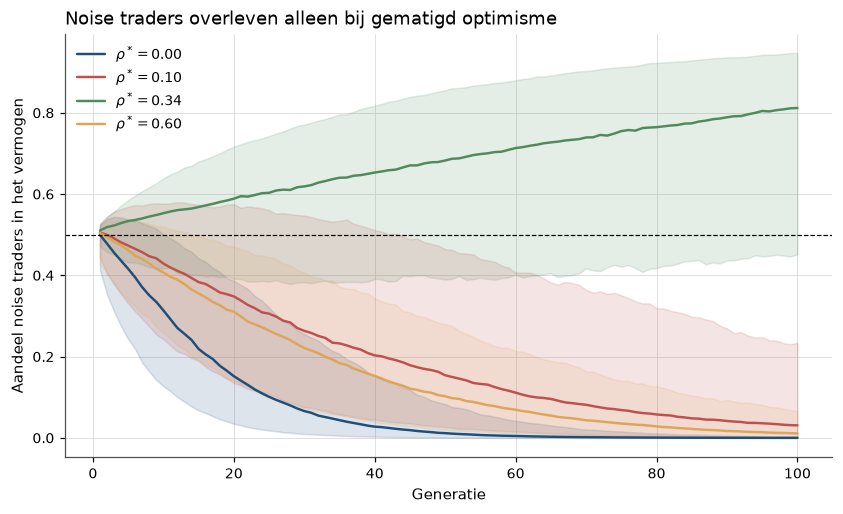

In [7]:
fig, ax = plt.subplots()
gens = np.arange(1, N_GEN + 1)
for i, (rs, d) in enumerate(dyn.items()):
    ax.plot(gens, np.median(d["share"], axis=1), color=hap.plotting.COLORS[i], label=f"$\\rho^* = {rs:.2f}$")
    ax.fill_between(gens, *np.percentile(d["share"], [10, 90], axis=1), color=hap.plotting.COLORS[i], alpha=0.15)
ax.axhline(0.5, color="black", lw=0.8, ls="--")
ax.set_xlabel("Generatie")
ax.set_ylabel("Aandeel noise traders in het vermogen")
ax.set_title("Noise traders overleven alleen bij gematigd optimisme")
ax.legend()
plt.show()

:::{figure} #cel-behavioral-dssw-sim
:label: fig-behavioral-dssw-sim
:width: 90%

Mediaan en 10e–90e percentiel van het vermogensaandeel van een noise-trader-dynastie die
met gelijk vermogen begint. Zonder optimisme ($\rho^{*} = 0$) of met te veel ($\rho^{*} = 0{,}6$)
verdwijnen noise traders; bij $\rho^{*} = \kappa/2$ groeien ze in de meeste paden naar een
meerderheid. Over de eerste vijf generaties, een eeuw, liggen de banden van alle vier de
werelden over elkaar.
:::

Het gemiddelde verschil in geldrendement ligt in alle vier de werelden binnen een honderdste
van [](#eq-behavioral-dssw-rendement). Bij $\rho^{*} = 0$ en $0{,}6$ verdwijnen noise traders.
Bij $\rho^{*} = 0{,}1$ is de mediane log-groei per generatie zelfs hoger ($+0{,}023$) maar het
gemiddelde geldrendement lager ($-0{,}049$): de meeste generaties gaan licht vooruit, een
enkele gaat failliet, en na 100 generaties heeft nog 1,8% van de paden een aandeel boven de
helft, tegen 87% bij $\rho^{*} = \kappa/2$. Faillissementen (0,15% tot 5,7% van de paden) treffen
alleen noise traders.

Dan motief 1. Na vijf generaties, ruwweg een eeuw, is het noise-traderaandeel in de beste
wereld in 69% van de paden boven de helft, in de slechtste nog in 20%, en de standaardfout van
het gemiddelde rendementsverschil over 100 generaties is even groot als het verschil zelf. Of
irrationele beleggers worden weggeselecteerd, vraagt meer geschiedenis dan er bestaat.

### (b) Hoe gevoelig is de evaluatieperiode voor de premie?

Volgens [](#eq-behavioral-bt) daalt $h^{*}$ met het *kwadraat* van de premie, en die premie
heeft een standaardfout van ongeveer twee procentpunt. We laten maandelijkse log-rendementen
normaal verdeeld zijn met de momenten van 1926–1990 (aandelen 9,3% gemiddeld en 20,3%
volatiliteit per jaar, obligaties 4,5% en 7,5%), berekenen de CPT-waarde op 400 kwantielen
voor horizons van 1 tot 60 maanden, en zoeken de kruising: eerst als functie van de ware
premie, dan voor 1000 steekproeven van 65 jaar met geschatte momenten.

In [8]:
N_GRID, H_MAX = 400, 60
Z_GRID = stats.norm.ppf((np.arange(N_GRID) + 0.5) / N_GRID)
H_MONTHS = np.arange(1, H_MAX + 1)
MOMENTS_1926_1990 = {"m_s": 0.0935 / 12, "s_s": 0.2032 / np.sqrt(12), "m_b": 0.0448 / 12, "s_b": 0.0753 / np.sqrt(12)}


def cpt_lognormal(m, s):
    """CPT value (rows: parameter sets, columns: horizons) of exp(m h + s sqrt(h) z) - 1."""
    m, s = np.atleast_1d(m)[:, None, None], np.atleast_1d(s)[:, None, None]
    x = np.expm1(m * H_MONTHS[None, :, None] + s * np.sqrt(H_MONTHS)[None, :, None] * Z_GRID)
    n_sets = x.shape[0]
    return cpt_equal(x.reshape(-1, N_GRID), is_sorted=True).reshape(n_sets, H_MAX)


def crossing_horizon(v_stock, v_bond):
    """First horizon (months, linearly interpolated) where stocks' CPT value reaches bonds'."""
    diff = v_stock - v_bond
    out = np.full(diff.shape[0], np.nan)
    for row, d in enumerate(diff):
        idx = np.flatnonzero((d[:-1] < 0) & (d[1:] >= 0))
        if len(idx):
            k = idx[0]
            out[row] = H_MONTHS[k] + d[k] / (d[k] - d[k + 1])
    return out


premia = np.linspace(0.02, 0.10, 17)                         # annual log premium of stocks over bonds
mom = MOMENTS_1926_1990
v_bond = cpt_lognormal(mom["m_b"], mom["s_b"])
v_stock = cpt_lognormal(mom["m_b"] + premia / 12, np.full_like(premia, mom["s_s"]))
h_star_premium = crossing_horizon(v_stock, np.repeat(v_bond, len(premia), axis=0))
print(f"premie 1926-1990: {12 * (mom['m_s'] - mom['m_b']):.2%}, h* = "
      f"{np.interp(12 * (mom['m_s'] - mom['m_b']), premia, h_star_premium):.1f} maanden")

premie 1926-1990: 4.87%, h* = 6.8 maanden


In [9]:
N_SAMPLES, N_MONTHS = 1000, 65 * 12
draw_s = mom["m_s"] + mom["s_s"] * rng.standard_normal((N_SAMPLES, N_MONTHS))
draw_b = mom["m_b"] + mom["s_b"] * rng.standard_normal((N_SAMPLES, N_MONTHS))
h_star_samples = crossing_horizon(cpt_lognormal(draw_s.mean(axis=1), draw_s.std(axis=1, ddof=1)),
                                  cpt_lognormal(draw_b.mean(axis=1), draw_b.std(axis=1, ddof=1)))
premium_hat = 12 * (draw_s.mean(axis=1) - draw_b.mean(axis=1))
pd.Series({"SD geschatte premie (%-punt)": 100 * premium_hat.std(),
           "h* mediaan (maanden)": np.nanmedian(h_star_samples),
           "h* 10e percentiel": np.nanpercentile(h_star_samples, 10),
           "h* 90e percentiel": np.nanpercentile(h_star_samples, 90),
           "fractie zonder kruising binnen 60 maanden": np.isnan(h_star_samples).mean()}).round(3)

SD geschatte premie (%-punt)                  2.746
h* mediaan (maanden)                          6.843
h* 10e percentiel                             3.070
h* 90e percentiel                            20.010
fractie zonder kruising binnen 60 maanden     0.018
dtype: float64

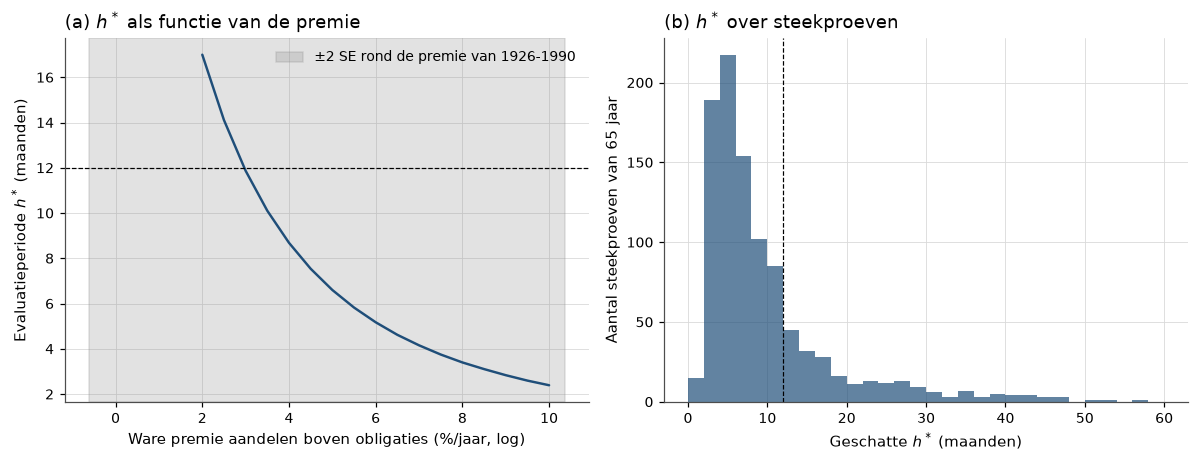

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(100 * premia, h_star_premium, color=hap.plotting.COLORS[0])
true_premium = 12 * (mom["m_s"] - mom["m_b"])
axes[0].axvspan(100 * (true_premium - 2 * premium_hat.std()), 100 * (true_premium + 2 * premium_hat.std()),
                color=hap.plotting.COLORS[7], alpha=0.25, label="$\\pm 2$ SE rond de premie van 1926-1990")
axes[0].axhline(12, color="black", lw=0.8, ls="--")
axes[0].set_xlabel("Ware premie aandelen boven obligaties (%/jaar, log)")
axes[0].set_ylabel("Evaluatieperiode $h^*$ (maanden)")
axes[0].set_title("(a) $h^*$ als functie van de premie")
axes[0].legend()
axes[1].hist(h_star_samples[~np.isnan(h_star_samples)], bins=np.arange(0, 61, 2), color=hap.plotting.COLORS[0], alpha=0.7)
axes[1].axvline(12, color="black", lw=0.8, ls="--")
axes[1].set_xlabel("Geschatte $h^*$ (maanden)")
axes[1].set_ylabel("Aantal steekproeven van 65 jaar")
axes[1].set_title("(b) $h^*$ over steekproeven")
fig.tight_layout()
plt.show()

:::{figure} #cel-behavioral-bt-sim
:label: fig-behavioral-bt-sim
:width: 100%

Links: de evaluatieperiode waarbij een CPT-belegger onverschillig is tussen aandelen en
obligaties daalt steil met de premie; binnen twee standaardfouten van de premie van
1926–1990 bedekt de grijze band van twee standaardfouten het hele getoonde bereik, van 17
maanden bij 2% tot 2,4 maanden bij 10%. Rechts: dezelfde onzekerheid als verdeling van de
schatter over 1000 steekproeven van 65 jaar; de stippellijn is één jaar.
:::

Bij de momenten van 1926–1990, met een log-premie van aandelen boven obligaties van 4,87%
per jaar, is $h^{*} = 6{,}8$ maanden. Maar die premie is over 65 jaar geschat met een
standaardfout van 2,7 procentpunt, en een verschuiving van die grootte verplaatst $h^{*}$ over
de hele grafiek. Over 1000 steekproeven is de mediaan van de geschatte $h^{*}$ 6,8 maanden,
het 10e en 90e percentiel liggen op 3,1 en 20 maanden, en in 1,8% van de steekproeven halen
aandelen obligaties binnen vijf jaar niet in. "Ongeveer een jaar" wordt door de data
toegestaan, niet afgedwongen.

## Replicatie op echte data

### De Bondt-Thaler: lange-termijnomkering

```{admonition} Replicatie
:class: seealso

**Bron.** Werner De Bondt en Richard Thaler, *Does the Stock Market Overreact?*, Journal of
Finance 1985 {cite}`DeBondtThaler1985`; voor de risicolezing Fama en French 1996
{cite}`FamaFrench1996`.

**Wat.** De kernuitkomst op p. 799: over zestien niet-overlappende testperioden van drie
jaar tussen januari 1933 en december 1980 verslaan portefeuilles van de 35 grootste
verliezers de markt na 36 maanden met gemiddeld 19,6%, terwijl de 35 grootste winnaars
ongeveer 5,0% achterblijven, een verschil van 24,6% ($t = 2{,}20$). Het effect is
asymmetrisch (vooral verliezers) en valt grotendeels in januari: in maand 1, 13 en 25 behalen
de verliezers 8,1%, 5,6% en 4,0% excess rendement. Fama en French (1996) melden dat de
lange-termijnomkering in het driefactormodel grotendeels verdwijnt.

**Data hier.** Kenneth French Data Library: de LT-reversalfactor (`F-F_LT_Reversal_Factor`),
de tien waarde- en gelijkgewogen decielen op prior 60-13 (`10_Portfolios_Prior_60_13`), de
zes size-portefeuilles waaruit de factor is gebouwd (`6_Portfolios_ME_Prior_60_13`) en de
FF3-factoren, maandelijks 1931-01 t/m 2026-07, via `hap.data.french(...)`.

**Verschil met het origineel.** DBT vormden elke drie jaar portefeuilles van de 35 of 50
extreemste NYSE-aandelen op 36 maanden marktgecorrigeerd rendement en hielden die drie jaar
vast. French sorteert elke maand NYSE-, AMEX- en NASDAQ-aandelen op het rendement van $t-60$
tot $t-13$ met NYSE-breekpunten: grotere, minder extreme, maandelijks herbalanceerde
portefeuilles.

**Verwachte afwijking.** Over 1933–1980 een positief verliezers-min-winnaarsrendement, groter
bij gelijk- dan bij waardeweging, en een positieve CAPM-alfa; een FF3-alfa die niet
significant van nul verschilt voor de LT-reversalfactor en het waardegewogen verschil, met
een positieve lading op HML; na 1980 een kleinere premie.
Is het teken van de HML-lading of van het ruwe verschil negatief, dan zit er een fout in de
code.
```

In [11]:
ff3 = hap_data.french("F-F_Research_Data_Factors")
lt_rev = hap_data.french("F-F_LT_Reversal_Factor")["LT_Rev"]
dec_vw = hap_data.french("10_Portfolios_Prior_60_13")
dec_ew = hap_data.french("10_Portfolios_Prior_60_13", table="Equal Weight")
six = hap_data.french("6_Portfolios_ME_Prior_60_13")

rev_from_six = 0.5 * (six["SMALL LoPRIOR"] + six["BIG LoPRIOR"]) - 0.5 * (six["SMALL HiPRIOR"] + six["BIG HiPRIOR"])
print(f"max |LT_Rev uit zes portefeuilles - LT_Rev| = {(rev_from_six - lt_rev).abs().max():.5f}")
reversal = {"LT_Rev (French)": lt_rev,
            "deciel 1-10 gelijkgewogen": dec_ew["Lo PRIOR"] - dec_ew["Hi PRIOR"],
            "deciel 1-10 waardegewogen": dec_vw["Lo PRIOR"] - dec_vw["Hi PRIOR"]}

max |LT_Rev uit zes portefeuilles - LT_Rev| = 0.00010


In [12]:
def alpha_row(y, start, end, lags=6):
    """Mean, CAPM and FF3 alphas (% per month) with Newey-West t-values over [start, end]."""
    frame = pd.concat([y.rename("y"), ff3], axis=1, sort=True).loc[start:end].dropna()
    fits = {name: hap.stats.newey_west(frame["y"], frame[cols], lags=lags)
            for name, cols in {"gem.": [], "CAPM": ["Mkt-RF"], "FF3": ["Mkt-RF", "SMB", "HML"]}.items()}
    return {"gem. (%/mnd)": 100 * fits["gem."].params.iloc[0], "t": fits["gem."].tvalues.iloc[0],
            "CAPM-alfa": 100 * fits["CAPM"].params.iloc[0], "t(CAPM)": fits["CAPM"].tvalues.iloc[0],
            "FF3-alfa": 100 * fits["FF3"].params.iloc[0], "t(FF3)": fits["FF3"].tvalues.iloc[0],
            "bèta HML": fits["FF3"].params["HML"], "bèta SMB": fits["FF3"].params["SMB"], "maanden": len(frame)}


periods = {"1933-1980 (DBT)": ("1933-01", "1980-12"), "1963:07-1980": ("1963-07", "1980-12"),
           "1981-2026": ("1981-01", "2026-12"), "1933-2026": ("1933-01", "2026-12")}
pd.DataFrame({(p, name): alpha_row(y, a, b) for p, (a, b) in periods.items() for name, y in reversal.items()}).T.round(3)

gem. (%/mnd)      t  CAPM-alfa  \
1933-1980 (DBT) LT_Rev (French)                   0.375  1.954      0.214   
                deciel 1-10 gelijkgewogen         1.358  3.452      0.991   
                deciel 1-10 waardegewogen         0.721  2.094      0.456   
1963:07-1980    LT_Rev (French)                   0.402  2.273      0.410   
                deciel 1-10 gelijkgewogen         1.396  4.683      1.393   
                deciel 1-10 waardegewogen         0.714  1.975      0.725   
1981-2026       LT_Rev (French)                   0.148  1.075      0.135   
                deciel 1-10 gelijkgewogen         0.379  1.420      0.363   
                deciel 1-10 waardegewogen         0.092  0.329      0.056   
1933-2026       LT_Rev (French)                   0.264  2.222      0.170   
                deciel 1-10 gelijkgewogen         0.881  3.629      0.671   
                deciel 1-10 waardegewogen         0.415  1.852      0.252   

                                           t(CAPM)  FF3-alfa  t(FF3)  \
1933-1980 (DBT) LT_Rev (French)              1.461    -0.033  -0.299   
                deciel 1-10 gelijkgewogen    3.526     0.410   1.992   
                deciel 1-10 waardegewogen    1.716     0.012   0.058   
1963:07-1980    LT_Rev (French)              2.435     0.112   0.911   
                deciel 1-10 gelijkgewogen    4.856     0.675   2.421   
                deciel 1-10 waardegewogen    2.099     0.006   0.020   
1981-2026       LT_Rev (French)              0.903    -0.018  -0.159   
                deciel 1-10 gelijkgewogen    1.374     0.255   1.141   
                deciel 1-10 waardegewogen    0.189    -0.259  -1.225   
1933-2026       LT_Rev (French)              1.637    -0.029  -0.350   
                deciel 1-10 gelijkgewogen    3.523     0.324   2.028   
                deciel 1-10 waardegewogen    1.280    -0.107  -0.715   

                                           bèta HML  bèta SMB  maanden  
1933-1980 (DBT) LT_Rev (French)               0.777     0.240    576.0  
                deciel 1-10 gelijkgewogen     1.484     1.208    576.0  
                deciel 1-10 waardegewogen     1.214     0.770    576.0  
1963:07-1980    LT_Rev (French)               0.656     0.117    210.0  
                deciel 1-10 gelijkgewogen     1.127     0.759    210.0  
                deciel 1-10 waardegewogen     1.279     0.603    210.0  
1981-2026       LT_Rev (French)               0.474     0.345    547.0  
                deciel 1-10 gelijkgewogen     0.428     0.688    547.0  
                deciel 1-10 waardegewogen     1.010     0.884    547.0  
1933-2026       LT_Rev (French)               0.601     0.317   1123.0  
                deciel 1-10 gelijkgewogen     0.997     1.065   1123.0  
                deciel 1-10 waardegewogen     1.057     0.831   1123.0

In [13]:
dbt_windows = pd.period_range("1933-01", "1980-12", freq="M").year.map(lambda y: (y - 1933) // 3)
three_year = pd.DataFrame({name: y.loc["1933-01":"1980-12"].groupby(np.asarray(dbt_windows)).apply(lambda x: (1 + x).prod() - 1)
                           for name, y in reversal.items()})
pd.DataFrame({"gem. 36-maandsrendement (%)": 100 * three_year.mean(),
              "t over 16 perioden": three_year.mean() / (three_year.std() / np.sqrt(len(three_year))),
              "fractie perioden > 0": (three_year > 0).mean()}).round(3)

,gem. 36-maandsrendement (%),t over 16 perioden,fractie perioden > 0
LT_Rev (French),17.300,1.658,0.625
deciel 1-10 gelijkgewogen,80.662,2.197,0.688
deciel 1-10 waardegewogen,39.984,1.780,0.562


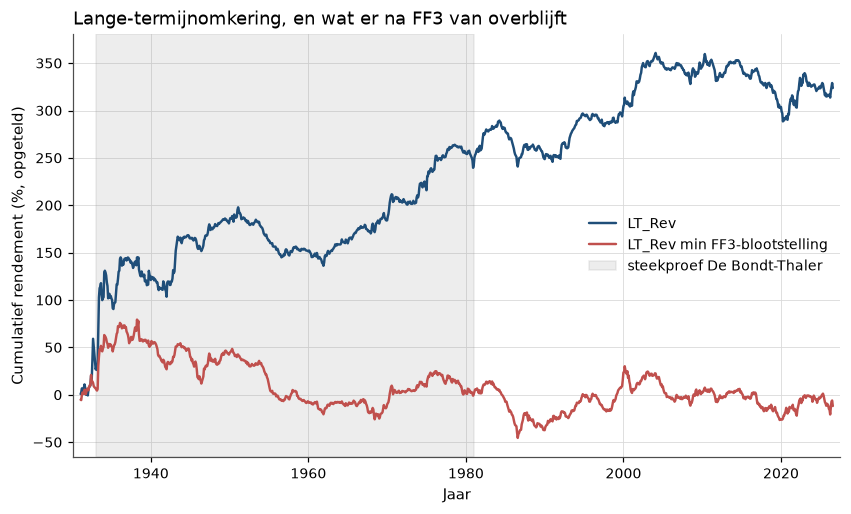

In [14]:
frame = pd.concat([lt_rev.rename("y"), ff3], axis=1, sort=True).dropna()
fit = hap.stats.newey_west(frame["y"], frame[["Mkt-RF", "SMB", "HML"]])
hedged = frame["y"] - frame[["Mkt-RF", "SMB", "HML"]] @ fit.params[["Mkt-RF", "SMB", "HML"]]
fig, ax = plt.subplots()
ax.plot(frame.index, 100 * frame["y"].cumsum(), color=hap.plotting.COLORS[0], label="LT_Rev")
ax.plot(frame.index, 100 * hedged.cumsum(), color=hap.plotting.COLORS[1], label="LT_Rev min FF3-blootstelling")
ax.axvspan(pd.Timestamp("1933-01-01"), pd.Timestamp("1980-12-31"), color=hap.plotting.COLORS[7], alpha=0.15,
           label="steekproef De Bondt-Thaler")
hap.plotting.timeline_axis(ax)
ax.set_xlabel("Jaar")
ax.set_ylabel("Cumulatief rendement (%, opgeteld)")
ax.set_title("Lange-termijnomkering, en wat er na FF3 van overblijft")
ax.legend()
plt.show()

:::{figure} #cel-behavioral-ltrev
:label: fig-behavioral-ltrev
:width: 90%

De lange-termijnomkering (blauw) levert tot 1980 gestaag op en daarna nauwelijks. Haal
de blootstelling aan markt, SMB en HML eruit (rood, met ladingen over de hele steekproef),
en er blijft over de hele eeuw niets over: wat De Bondt en Thaler als overreactie lazen, is
statistisch grotendeels de waardepremie.
:::

De factor van French is tot op afronding van de gepubliceerde procenten het verschil tussen
de gemiddelde verliezers- en winnaarsportefeuilles uit de zes size-portefeuilles. Over de
periode van De Bondt en Thaler verdient het gelijkgewogen verschil tussen het verliezers- en
het winnaarsdeciel 1,36% per maand ($t = 3{,}45$), het waardegewogen verschil 0,72%
($t = 2{,}09$) en de LT-reversalfactor 0,38% ($t = 1{,}95$). Samengesteld over hun zestien
driejaarsperioden levert het gelijkgewogen verschil gemiddeld 81% op, met $t = 2{,}20$ over
de zestien perioden, toevallig hun $t$-waarde; het grotere getal is een samengesteld
long-short-rendement van decielen, geen marktgecorrigeerd residu van 35 aandelen. Teken en
significantie kloppen, de omvang is niet vergelijkbaar. En motief 1: 0,38% per maand met
$t = 1{,}95$ betekent een standaardfout van 2,3 procentpunt per jaar.

Dan de risicolezing. Verliezers hebben hier een hogere marktbèta, dus de CAPM-alfa's zijn
kleiner, en FF3 neemt de rest: de alfa van de factor is $-0{,}03\%$ ($t = -0{,}30$) bij een
HML-lading van 0,78, die van het waardegewogen verschil 0,01%. Alleen het gelijkgewogen
verschil houdt 0,41% over ($t = 1{,}99$). Na 1980 is de factor 0,15% per maand ($t = 1{,}08$);
de gehedgede reeks in [](#fig-behavioral-ltrev) is over de hele eeuw vlak.

### Benartzi-Thaler: de evaluatieperiode op historische rendementen

```{admonition} Replicatie
:class: seealso

**Bron.** Shlomo Benartzi en Richard Thaler, *Myopic Loss Aversion and the Equity Premium
Puzzle*, Quarterly Journal of Economics 1995 {cite}`BenartziThaler1995`.

**Wat.** De evaluatieperiode waarbij de CPT-waarde van aandelen gelijk is aan die van
obligaties. Benartzi en Thaler trokken met teruglegging uit de maandrendementen van CRSP over
1926–1990 en vergeleken de aandelenindex met schatkistpapier en vijfjaarsobligaties, nominaal
en reëel, bij de parameters van Tversky en Kahneman (1992). De break-evenperiode lag
"always between 9 and 12 months, or roughly one year" (in de inleiding: 9 tot 13 maanden),
met 11–12 maanden voor hun voorkeursvergelijking, nominale aandelen tegen vijfjaarsobligaties.
Met een lineaire waardefunctie en ongewogen kansen werd het 8 maanden. Deze getallen komen uit
de NBER-werkversie (w4369, 1993, p. 13–16); de tijdschriftversie kan in formulering afwijken.

**Data hier.** Goyal-Welch, maandelijks 1926-01 t/m 2025-12, via
`hap.data.goyal_welch("monthly")`: `CRSP_SPvw` (S&P 500 met dividend) voor aandelen, `ltr`
(rendement op langlopende staatsobligaties) voor obligaties en `infl` voor reële rendementen.

**Verschil met het origineel.** BT gebruikten CRSP-reeksen voor schatkistpapier en
vijfjaarsobligaties; de gratis data bevatten alleen langlopende staatsobligaties (`ltr`), die
volatieler zijn. Dat verlaagt de CPT-waarde van obligaties en verkort $h^{*}$. We trekken zoals
zij maanden met teruglegging (20 000 trekkingen per horizon, dezelfde voor elke variant), maar
rekenen de CPT-waarde exact uit in plaats van op twintig punten van de verdeling. Reëel
betekent hier gedefleerd met `infl`.

**Verwachte afwijking.** Een evaluatieperiode in de orde van één jaar (tussen ruwweg een
halfjaar en anderhalf jaar) over 1926–1990 bij $\lambda = 2{,}25$; een kortere periode bij een
hogere premie en een langere bij een lagere; bij hogere $\lambda$ een langere periode. Ligt
$h^{*}$ bij tien jaar of komt er geen kruising, dan zit er een fout in de code.
```

In [15]:
gw = hap_data.goyal_welch("monthly")
N_BOOT = 20_000


boot_idx = rng.integers(0, 10**9, size=(N_BOOT, H_MAX))       # common random numbers for every call


def bootstrap_h_star(start, end, real=False, shift=0.0, lam=LAMBDA):
    """BT-style h*: bootstrap months, compound to h months, compare CPT values of stocks and bonds."""
    data = gw.loc[start:end, ["CRSP_SPvw", "ltr", "infl"]].dropna()
    deflate = (1 + data["infl"]) if real else 1.0
    stock = ((1 + data["CRSP_SPvw"] + shift / 12) / deflate).to_numpy()
    bond = ((1 + data["ltr"]) / deflate).to_numpy()
    idx = boot_idx % len(data)
    v_s = cpt_equal((np.cumprod(stock[idx], axis=1) - 1).T, lam=lam)       # rows = horizons
    v_b = cpt_equal((np.cumprod(bond[idx], axis=1) - 1).T, lam=lam)
    return v_s, v_b, crossing_horizon(v_s[None], v_b[None]).item()


v_s_bt, v_b_bt, h_bt = bootstrap_h_star("1926-01", "1990-12")
diff = gw.loc["1926":"1990", "CRSP_SPvw"] - gw.loc["1926":"1990", "ltr"]
se_premium = np.sqrt(12) * diff.std() / np.sqrt(len(diff) / 12)
rows = {}
for label, (a, b) in {"1926-1990": ("1926-01", "1990-12"), "1926-2025": ("1926-01", "2025-12")}.items():
    for real in (False, True):
        rows[(label, "reëel" if real else "nominaal")] = {
            "premie (%/jaar)": 1200 * (gw.loc[a:b, "CRSP_SPvw"] - gw.loc[a:b, "ltr"]).mean(),
            "h* (maanden)": bootstrap_h_star(a, b, real)[2],
            "h*, premie - 2 SE": bootstrap_h_star(a, b, real, shift=-2 * se_premium)[2],
            "h*, premie + 2 SE": bootstrap_h_star(a, b, real, shift=+2 * se_premium)[2],
            "h*, lambda = 2.5": bootstrap_h_star(a, b, real, lam=2.5)[2]}
print(f"SE van de premie 1926-1990: {se_premium:.2%} per jaar")
pd.DataFrame(rows).T.round(2)

SE van de premie 1926-1990: 2.55% per jaar


premie (%/jaar)  h* (maanden)  h*, premie - 2 SE  \
1926-1990 nominaal             6.68          7.50              41.35   
          reëel                6.68          5.69              35.48   
1926-2025 nominaal             6.11          5.55              53.29   
          reëel                6.11          4.70              53.30   

                    h*, premie + 2 SE  h*, lambda = 2.5  
1926-1990 nominaal               2.49              9.55  
          reëel                  1.96              7.56  
1926-2025 nominaal               2.07              7.09  
          reëel                  1.71              5.80

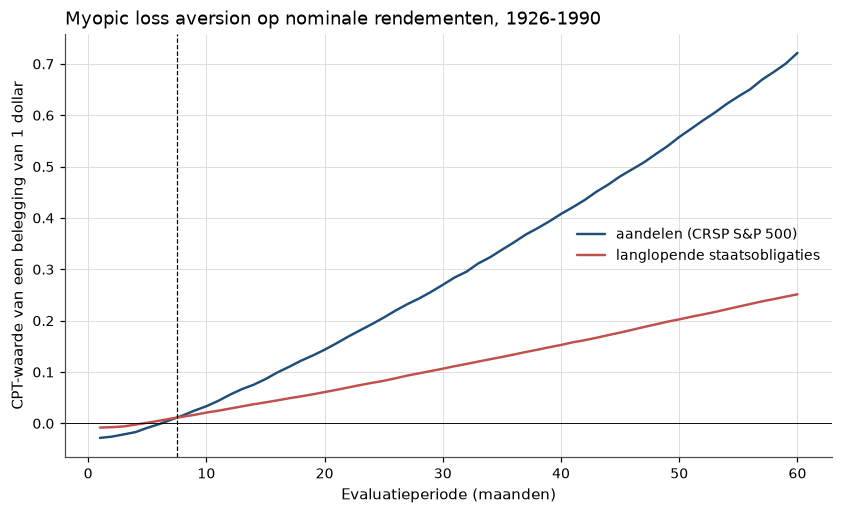

In [16]:
fig, ax = plt.subplots()
ax.plot(H_MONTHS, v_s_bt, color=hap.plotting.COLORS[0], label="aandelen (CRSP S&P 500)")
ax.plot(H_MONTHS, v_b_bt, color=hap.plotting.COLORS[1], label="langlopende staatsobligaties")
ax.axvline(h_bt, color="black", lw=0.8, ls="--")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("Evaluatieperiode (maanden)")
ax.set_ylabel("CPT-waarde van een belegging van 1 dollar")
ax.set_title("Myopic loss aversion op nominale rendementen, 1926-1990")
ax.legend()
plt.show()

:::{figure} #cel-behavioral-bt-data
:label: fig-behavioral-bt-data
:width: 90%

De CPT-waarde van aandelen is bij korte evaluatieperioden lager dan die van obligaties,
omdat verliezen vaak voorkomen en $2{,}25$ keer tellen; naarmate de periode langer wordt,
halen aandelen obligaties in. De stippellijn is de evaluatieperiode waarbij de belegger
onverschillig is.
:::

Over 1926–1990 halen nominale aandelen de langlopende obligaties na 7,5 maanden in, reëel na
5,7; tot en met 2025 na 5,6 en 4,7. Dat is korter dan de 9 tot 13 maanden van Benartzi en
Thaler, in de richting die de volatielere obligatiereeks voorspelt; met $\lambda = 2{,}5$ wordt
het 9,6 maanden. De orde van grootte klopt. Maar de premie van 6,7% heeft een standaardfout van
2,55 procentpunt, en twee standaardfouten lager of hoger geeft 41 of 2,5 maanden: wie $h^{*}$
meet, meet vooral de premie.

```{note}
De individuele accountgegevens achter het disposition effect en overconfidence zijn niet
gratis en kunnen hier niet worden gerepliceerd; we noemen de gepubliceerde getallen.
{cite:t}`Odean1998` volgde 10 000 rekeningen bij een grote discountbroker, januari 1987 tot
december 1993. Het aandeel gerealiseerde winsten (*proportion of gains realized*, PGR) was over
het hele jaar 0,148, het aandeel gerealiseerde verliezen (PLR) 0,098; alleen in december, als
een verlies belastingvoordeel oplevert, was PLR hoger (0,128 tegen 0,108). Verkochte winnaars
deden het in het jaar erna 3,4 procentpunt beter dan aangehouden verliezers (tabel VI).
{cite:t}`BarberOdean2000` bekeken 66 465 huishoudens bij een grote discountbroker over
1991–1996: "those that trade most earn an annual return of 11.4 percent, while the market
returns 17.9 percent"; het gemiddelde huishouden verdiende 16,4% per jaar en had een
omloopsnelheid van 75%. {cite:t}`BarberOdean2001` vonden bij ruim 35 000 huishoudens
(februari 1991 tot januari 1997) dat mannen 45% meer handelen dan vrouwen, en dat handelen het
netto rendement van mannen met 2,65 en dat van vrouwen met 1,72 procentpunt per jaar verlaagt;
alleenstaande mannen handelen 67% meer dan alleenstaande vrouwen.
```

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Behavioral finance gaf de feiten uit de vorige lectures een
mechanisme: excess volatility en voorspelbaarheid via traag sentiment, momentum en omkering
via BSV, DHS en HS, de equity premium via myopic loss aversion, handelspatronen van
particulieren via prospect theory en overconfidence, tweelingaandelen en carve-outs via
limits of arbitrage. En het weerlegde het argument dat irrationele beleggers vanzelf
verdwijnen. In DSSW verdienen ze onder voorwaarden meer, en bij Shleifer en
Vishny is arbitrage het zwakst wanneer ze het meest nodig is, zoals LTCM in 1998 liet zien
([](#04-22-risk-management)).

**Waar het breekt.** Bij de toets. Onze replicatie vindt de omkering van De Bondt en Thaler
terug (1,36% per maand gelijkgewogen over 1933–1980, $t = 3{,}45$), maar voor de factor valt ze
vrijwel geheel in januari (3,35% per januarimaand, 0,11% in de andere maanden, zie
[](#ex-behavioral-3)), ze is na 1980 zwak, en het driefactormodel slokt haar op: een FF3-alfa
van $-0{,}03\%$ bij een HML-lading van 0,78. De evaluatieperiode van Benartzi en Thaler ligt
binnen twee standaardfouten van de premie ergens tussen 2,5 en 41 maanden. Een gedragsmodel
met een vrije parameter per feit verklaart veel en verbiedt weinig.

**Risico of vergissing?** De Chicago-lezing: verliezers van vijf jaar zijn bedrijven in
*distress* (financiële nood) met een hoge boek-marktwaarde, de omkering is de waardepremie, en
HML beprijst een risico dat in slechte tijden uitkomt {cite}`FamaFrench1996`. De equity premium
is dan een risicopremie waarvoor een beter model van marginaal nut nodig is, en daarover gaat
[](#05-27-drie-antwoorden). De Yale- en Harvard-lezing: de waardepremie *is* de overreactie.
{cite:t}`LakonishokShleiferVishny1994` lazen haar als extrapolatie van groei, en HML slokt de
omkering op omdat HML dezelfde verkeerd geprijsde aandelen bevat. {prf:ref}`prop-behavioral-joint`
zegt waarom prijzen en rendementen dit niet beslissen; marginaal nut, gemeten verwachtingen
of shortingkosten zouden het kunnen, maar die data kwamen later en besliste ook niet. Het
praktijkmotief van
Santa-Clara maakt het concreet: wie verliezers koopt, draagt ofwel beprijsd distress-risico,
ofwel denkt hij de vergissing van anderen te zien. En DSSW en Shleifer-Vishny voegen eraan toe
dat ook wie gelijk heeft, failliet kan gaan voordat de prijs hem gelijk geeft.

**Wat er daarna kwam.** Noise traders bleven, maar als bouwsteen: in het model van Kyle zijn
zij degenen die geïnformeerde handel mogelijk maken, en de vraag verschuift van *of* prijzen
fout zijn naar *hoe* informatie via orders in prijzen terechtkomt, zie
[](#04-24-microstructuur).

## Oefeningen

:::{exercise}
:label: ex-behavioral-1

**Het venster van DSSW.** Neem de parameters uit de simulatie ($r = 1$, $\mu = 0{,}25$,
$\sigma_\rho = 0{,}3$, $\gamma = 60$).

1. Bereken de grenzen van het interval in {prf:ref}`prop-behavioral-dssw-rendement` en de
   maximale $\E[\Delta R]$.
2. Hoe groot moet $\mu$ minimaal zijn opdat er *enige* $\rho^{*}$ bestaat waarbij noise
   traders meer verdienen? Leg economisch uit waarom een klein aantal noise traders nooit
   meer kan verdienen.
3. Controleer (1) met de simulatiefunctie voor $\rho^{*} \in \{0{,}15;\ 0{,}20;\ 0{,}45;\ 0{,}55\}$.
:::

:::{solution} ex-behavioral-1
:class: dropdown

**(1)** De wortels van $(\rho^{*})^{2} - \kappa\rho^{*} + \sigma_\rho^{2} = 0$ met $\kappa = 0{,}675$
en $\sigma_\rho^{2} = 0{,}09$ zijn $0{,}183$ en $0{,}492$; het maximum in $\rho^{*} = \kappa/2$ is
$\kappa/2 - (\kappa^{2}/4 + \sigma_\rho^{2})/\kappa = 0{,}0354$.

**(2)** Er is een kruising als $\kappa > 2\sigma_\rho$, dus
$\mu > (1+r)^{2}/(\gamma\sigma_\rho) = 4/18 = 0{,}222$. Met weinig noise traders is het
herverkooprisico dat ze creëren klein ($\Var(p) \propto \mu^{2}$), dus nemen de sophisticated
beleggers bijna al het risico over, en blijven voor de noise traders alleen de
*price pressure*- en *buy high, sell low*-effecten over.

In [17]:
disc = np.sqrt(KAPPA**2 - 4 * SIGMA_RHO**2)
print(f"interval: ({(KAPPA - disc) / 2:.3f}, {(KAPPA + disc) / 2:.3f}), "
      f"max E[dR] = {KAPPA / 2 - (KAPPA**2 / 4 + SIGMA_RHO**2) / KAPPA:.4f}")
print(f"minimale mu: {(1 + R_GEN) ** 2 / (GAMMA_CARA * SIGMA_RHO):.3f}")
pd.Series({rs: dssw_dynasties(rs)["dR"].mean() for rs in [0.15, 0.20, 0.45, 0.55]},
          name="gem. dR (simulatie)").round(4)

interval: (0.183, 0.492), max E[dR] = 0.0354
minimale mu: 0.222


0.15   -0.0163
0.20    0.0085
0.45    0.0175
0.55   -0.0323
Name: gem. dR (simulatie), dtype: float64

Binnen het interval is het gesimuleerde verschil positief, erbuiten negatief: "noise traders
verdienen meer" geldt alleen in een smal gebied van genoeg noise traders en gematigd optimisme.
:::

:::{exercise}
:label: ex-behavioral-2

**Hoe hoog moet $\lambda$ zijn?** Gebruik de benadering [](#eq-behavioral-bt) met
$\sigma = 20\%$ en $r^{f} = 1\%$.

1. Welke $\lambda$ rechtvaardigt een premie van 6% bij een evaluatieperiode van één jaar?
   En bij vijf jaar?
2. Leid af hoe $h^{*}$ verandert als de premie met een factor $1 + \epsilon$ stijgt, voor
   kleine $\epsilon$ en $r^{f} = 0$.
3. Gebruik (2) om de onzekerheid in $h^{*}$ uit te drukken als de premie $6\% \pm 2\%$ is.
:::

:::{solution} ex-behavioral-2
:class: dropdown

**(1)** Los $\mu^{e} = \frac{\lambda-1}{\lambda+1}\left(\sigma\sqrt{2/(\pi h)} - r^{f}\right)$ op
naar $\lambda$: met $c = \sigma\sqrt{2/(\pi h)} - r^{f}$ is $\lambda = (c + \mu^{e})/(c - \mu^{e})$,
zolang $c > \mu^{e}$.

**(2)** Met $r^{f} = 0$ is $h^{*} \propto (\mu^{e})^{-2}$, dus $d\ln h^{*} = -2\, d\ln\mu^{e}$:
een premie die 10% hoger is, geeft een evaluatieperiode die ongeveer 20% korter is.

In [18]:
sigma, rf = 0.20, 0.01
for h in (1, 5):
    c = sigma * np.sqrt(2 / (np.pi * h)) - rf
    print(f"h = {h}: lambda = {(c + 0.06) / (c - 0.06):.2f}" if c > 0.06 else f"h = {h}: geen lambda (c = {c:.4f} <= 0.06)")
h_of = lambda mu_e, lam=LAMBDA: 2 * sigma**2 / np.pi / (rf + mu_e * (lam + 1) / (lam - 1)) ** 2
print("h* (maanden) bij premie 4%, 6%, 8%:", np.round([12 * h_of(m) for m in (0.04, 0.06, 0.08)], 1))

h = 1: lambda = 2.34
h = 5: lambda = 88.91
h* (maanden) bij premie 4%, 6%, 8%: [23.5 11.1  6.4]


**(1) en (3)** Bij een jaar volstaat $\lambda = 2{,}34$; bij vijf jaar is $\lambda \approx 89$
nodig. Bij $\lambda = 2{,}25$ is $h^{*}$ 23,5, 11,1 en 6,4 maanden bij 4%, 6% en 8%: een factor
3,7, iets minder dan (2) voorspelt omdat $r^{f} > 0$. De theorie is flexibel omdat het
gemiddelde slecht gemeten is.
:::

:::{exercise}
:label: ex-behavioral-3

**Januari en de omkering.** De Bondt en Thaler vonden dat een groot deel van de
overprestatie van verliezers in januari valt. Splits de gelijkgewogen
verliezers-min-winnaarsportefeuille (deciel 1 min 10) en `LT_Rev` in januari- en overige
maanden, over 1933–1980 en 1981–2026. Rapporteer gemiddelden met Newey-West $t$-waarden,
en schat de FF3-alfa van de niet-januarimaanden. Wat betekent de uitkomst voor de
overreactielezing?
:::

:::{solution} ex-behavioral-3
:class: dropdown

In [19]:
rows = {}
for p, (a, b) in {"1933-1980": ("1933-01", "1980-12"), "1981-2026": ("1981-01", "2026-12")}.items():
    for name in ("LT_Rev (French)", "deciel 1-10 gelijkgewogen"):
        y = reversal[name].loc[a:b]
        jan = y.index.month == 1
        for label, mask in (("januari", jan), ("overige maanden", ~jan)):
            fit = hap.stats.newey_west(y[mask], pd.DataFrame(index=y[mask].index), lags=6)
            rows[(p, name, label)] = {"gem. (%/mnd)": 100 * fit.params.iloc[0], "t": fit.tvalues.iloc[0]}
        rows[(p, name, "overige maanden, FF3-alfa")] = {
            k: v for k, v in alpha_row(y[~jan], a, b).items() if k in ("FF3-alfa", "t(FF3)")}
pd.DataFrame(rows).T.round(3)

gem. (%/mnd)  \
1933-1980 LT_Rev (French)           januari                           3.346   
                                    overige maanden                   0.105   
                                    overige maanden, FF3-alfa           NaN   
          deciel 1-10 gelijkgewogen januari                           9.780   
                                    overige maanden                   0.593   
                                    overige maanden, FF3-alfa           NaN   
1981-2026 LT_Rev (French)           januari                           1.365   
                                    overige maanden                   0.036   
                                    overige maanden, FF3-alfa           NaN   
          deciel 1-10 gelijkgewogen januari                           6.757   
                                    overige maanden                  -0.207   
                                    overige maanden, FF3-alfa           NaN   

                                                                   t  \
1933-1980 LT_Rev (French)           januari                    4.628   
                                    overige maanden            0.536   
                                    overige maanden, FF3-alfa    NaN   
          deciel 1-10 gelijkgewogen januari                    4.185   
                                    overige maanden            1.503   
                                    overige maanden, FF3-alfa    NaN   
1981-2026 LT_Rev (French)           januari                    2.291   
                                    overige maanden            0.277   
                                    overige maanden, FF3-alfa    NaN   
          deciel 1-10 gelijkgewogen januari                    5.622   
                                    overige maanden           -0.867   
                                    overige maanden, FF3-alfa    NaN   

                                                               FF3-alfa  \
1933-1980 LT_Rev (French)           januari                         NaN   
                                    overige maanden                 NaN   
                                    overige maanden, FF3-alfa    -0.040   
          deciel 1-10 gelijkgewogen januari                         NaN   
                                    overige maanden                 NaN   
                                    overige maanden, FF3-alfa     0.335   
1981-2026 LT_Rev (French)           januari                         NaN   
                                    overige maanden                 NaN   
                                    overige maanden, FF3-alfa    -0.100   
          deciel 1-10 gelijkgewogen januari                         NaN   
                                    overige maanden                 NaN   
                                    overige maanden, FF3-alfa    -0.309   

                                                               t(FF3)  
1933-1980 LT_Rev (French)           januari                       NaN  
                                    overige maanden               NaN  
                                    overige maanden, FF3-alfa  -0.344  
          deciel 1-10 gelijkgewogen januari                       NaN  
                                    overige maanden               NaN  
                                    overige maanden, FF3-alfa   1.454  
1981-2026 LT_Rev (French)           januari                       NaN  
                                    overige maanden               NaN  
                                    overige maanden, FF3-alfa  -0.874  
          deciel 1-10 gelijkgewogen januari                       NaN  
                                    overige maanden               NaN  
                                    overige maanden, FF3-alfa  -1.532

Over 1933–1980 verdient de factor in januari gemiddeld 3,35% ($t = 4{,}63$) en in de andere
elf maanden 0,11% ($t = 0{,}54$); voor het gelijkgewogen decielverschil is dat 9,78% tegen
0,59%. Na 1980 blijft het januari-effect (1,37% en 6,76%) terwijl de overige maanden rond nul
of negatief liggen, en de FF3-alfa's van de niet-januarimaanden zijn nergens significant.
Waarom zou de correctie van overreactie op januari wachten? Belastingverkopen van verliezers
in december en het terugveren in januari passen beter: één gedragsfeit kan uit meer dan één
gedrag bestaan.
:::